In [1]:
%load_ext autoreload
%autoreload 2
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import os
REDIS = os.environ.get('REDIS_SERVICE', "redis") #default=redis
REDIS_PORT = os.environ.get('REDIS_PORT', 6379) #default=6379
redis_max_connections = os.environ.get('REDIS_MAX_CONNECTIONS', 1024) #default=1024
redis_cache_size = os.environ.get('REDIS_CACHE_SIZE', 500)  #default=200
redis_cache_expire_time = os.environ.get('REDIS_CACHE_EXPIRE_TIME', 7*24*60*60)  #default=7*24*60*60
config_input_size = os.environ.get('IMAGE_INPUT_SIZE', 1024)  #default=1024
use_gpu = os.environ.get("SERVER_RUNTIME", "runc") == "nvidia"
user_focus_preload_scope = os.environ.get("PRELOAD_SCOPE", 5) #default scope=5
import time
import pickle
from rds import RedisAccess
from typing import List, Optional


In [2]:
def get_image_transform_from_image_pil(image):
    img_pil = image
    img_np = np.array(img_pil.convert("RGB").resize((512, 512)))
    img_np = img_np / 255.0
    img = torch.from_numpy(img_np).permute(2, 0, 1)
    img_mean=(0.485, 0.456, 0.406)
    img_std=(0.229, 0.224, 0.225)
    img_mean = torch.tensor(img_mean, dtype=torch.float32)[:, None, None]
    img_std = torch.tensor(img_std, dtype=torch.float32)[:, None, None]
    img -= img_mean
    img /= img_std
    return img

In [3]:
def get_input_points(clicks):
    """Get input points"""
    points, labels = [], []
    for click in clicks:
        points.append([click[0], click[1]])
        labels.append(1 if click[2] else 0)
    points, labels = np.array(points), np.array(labels)
    return points, labels

In [4]:
def predict(predictor,img,
            img_format: str,
            clicks: list,
            md5: str,
            pid: int,
            model_id: int,
            box: Optional[dict] = None,
    ):
    rds = RedisAccess(pid)
    tic = time.time()
    #image_bytes = base64.b64decode(img)
    #npimg = np.fromstring(img, dtype=np.uint8)
    md5 = str(model_id) + "_" + md5
    print("=======image_key:", md5)
    #rgb_image = get_rgb_image(npimg)
    np_image = np.array(img.convert("RGB"))

    if rds.redis_get("seg_image_cache_" + md5):
        cache_data = rds.redis_get("seg_image_cache_" + md5)
        cache_data = pickle.loads(cache_data)
        backbone_out = cache_data["image_embedding"]
        _, vision_feats, _, _ = predictor.model._prepare_backbone_features(backbone_out)
        if predictor.model.directly_add_no_mem_embed:
            vision_feats[-1] = vision_feats[-1] + predictor.model.no_mem_embed

        feats = [
            feat.permute(1, 2, 0).view(1, -1, *feat_size)
            for feat, feat_size in zip(vision_feats[::-1], predictor._bb_feat_sizes[::-1])
        ][::-1]
        predictor._features = {"image_embed": feats[-1], "high_res_feats": feats[:-1]}
        
        
        high_res_feats = cache_data.get('high_res_feats',None)
        predictor._is_image_set = True
        predictor._orig_hw = [np_image.shape[:2]]
    else:
        print("WARNING: can't find embedding in redis, calculate embedding now...", flush=True)
        # ###medical pre-process
        # status, error_msg, image_embedding = medical_pre_process_and_get_image_embedding(img)
        # if not status:
        #     return False, error_msg, {}
        # ######################
        backbone_out = predictor.set_image(np_image)
        image_tensor = get_image_transform_from_image_pil(img)
        
        data = {"image_embedding": backbone_out,'image':image_tensor}
        
        
        pickled_data = pickle.dumps(data)
        rds.redis_set("seg_image_cache_" + md5, pickled_data, ex=redis_cache_expire_time)
        
    toc = time.time()
    if box is not None:
        box = [min(box[0],box[2]),min(box[1],box[3]),max(box[0],box[2]),max(box[1],box[3])]
    
    input_points, input_labels = get_input_points(clicks)
    # predictor.set_image(rgb_image)
    if box is not None:
        masks, scores, logits = predictor.predict(
            point_coords=None,
            point_labels=None,
            box=box,
            multimask_output=True,
        )
    else:
        masks, scores, logits = predictor.predict(
            point_coords=input_points,
            point_labels=input_labels,
            multimask_output=True,
        )
    sorted_ind = np.argsort(scores)[::-1]
    masks = masks[sorted_ind]
    scores = scores[sorted_ind]
    logits = logits[sorted_ind]
    pred = masks[0] 
    #pred = (pred + 20) * 2.5
    #pred[pred < 0] = 0
    #pred = pred.astype('uint8')
    
    pred = pred.astype('uint8')

    result = {"mask": pred.tolist()}
    print(f"predict time: {time.time() - toc} s", flush=True)
    print(f"Inference took {time.time() - tic} s", flush=True)
    return True, "ok", result


In [13]:
from sam2.sam2_image_predictor import SAM2ImagePredictor
from sam2.build_sam import build_sam2
from PIL import Image

sam2_checkpoint = "/home/a70495/sam2/checkpoints/sam2.1_hiera_base_plus.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_b+.yaml"
device = torch.device("cpu")
sam =  build_sam2(config_file=model_cfg, ckpt_path=sam2_checkpoint, device=device)
predictor = SAM2ImagePredictor(sam)
rds = RedisAccess(0)

video_dir = "./videos/bedroom"
video_dir = "../../sam2/notebooks/videos/cat"

# scan all the JPEG frame names in this directory
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))
# inference_state = predictor.init_state(video_path=video_dir)
img_list = [{"md5": os.path.splitext(p)[0], "data":Image.open(os.path.join(video_dir,p))} for idx,p in enumerate(frame_names)]
model_id = "sam2.1_hiera_base_plus"

In [14]:
np.random.seed(3)

def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2) 
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))    

def show_masks(image, mask, score, point_coords=None, box_coords=None, input_labels=None, borders=True):
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    show_mask(mask, plt.gca(), borders=borders)
    if point_coords is not None:
        assert input_labels is not None
        show_points(point_coords, input_labels, plt.gca())
    if box_coords is not None:
        # boxes
        show_box(box_coords, plt.gca())

    plt.axis('off')
    plt.show()

In [17]:
img = img_list[0]["data"]
md5 = img_list[0]["md5"]
clicks = np.array([[500, 375,1]])

box = np.array([0, 100, 310, 380], dtype=np.float32)

pid = 0
model_id = model_id
status1,status2,result = predict(predictor,img,'jpg',clicks, md5,pid,model_id,box=box )
mask = np.array(result["mask"])

=======image_key: sam2.1_hiera_base_plus_2
predict time: 0.02794790267944336 s
Inference took 0.446321964263916 s


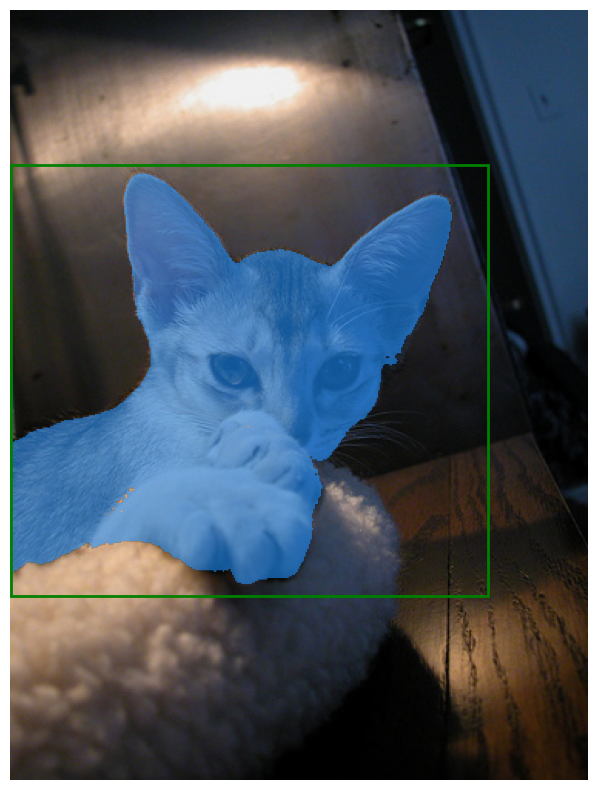

In [20]:
show_masks(img, mask, 1, box_coords=box ,borders=False)

In [9]:
np.save('mask.npy',mask)